plot the infor acc by LLM

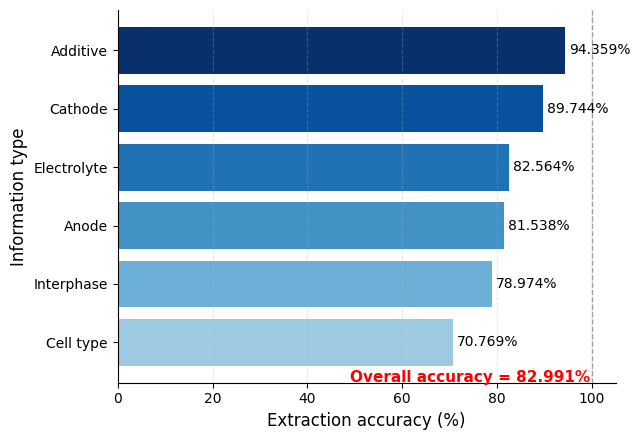

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Raw data
# =========================

total_count = 195

data = {
    "Cell type": 138,
    "Cathode": 175,
    "Anode": 159,
    "Additive": 184,
    "Electrolyte": 161,
    "Interphase": 154,
}

# =========================
# Calculate accuracy
# =========================

labels = list(data.keys())
correct = np.array(list(data.values()))
accuracy = correct / total_count * 100

# sort by accuracy
sorted_idx = np.argsort(accuracy)

labels = np.array(labels)[sorted_idx]
accuracy = accuracy[sorted_idx]

# overall accuracy
overall_accuracy = correct.sum() / (total_count * len(data)) * 100

# =========================
# Plot
# =========================

plt.figure(figsize=(6.5, 4.5))

# Nature-style blue gradient
colors = [
    "#9ecae1",
    "#6baed6",
    "#4292c6",
    "#2171b5",
    "#08519c",
    "#08306b",
]

colors = colors[:len(labels)]

bars = plt.barh(
    labels,
    accuracy,
    color=colors,
    linewidth=0.8
)

# Add accuracy text
for bar, acc in zip(bars, accuracy):
    plt.text(
        acc + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{acc:.3f}%",
        va="center",
        fontsize=10
    )

# dashed line at 100%
plt.axvline(
    100,
    linestyle="--",
    linewidth=1,
    color="gray",
    alpha=0.7
)

# Labels
plt.xlabel("Extraction accuracy (%)", fontsize=12)
plt.ylabel("Information type", fontsize=12)

# Overall accuracy text
plt.text(
    49,
    -0.67,
    f"Overall accuracy = {overall_accuracy:.3f}%",
    fontsize=11,
    fontweight="bold",
    color='red'
)

# Limits
plt.xlim(0, 105)

# Style tweaks (Nature-like)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Tight layout
plt.tight_layout()

# # Save figure (recommended formats)
# plt.savefig("LLM_extraction_accuracy.pdf", dpi=600, bbox_inches="tight")
# plt.savefig("LLM_extraction_accuracy.png", dpi=600, bbox_inches="tight")

plt.show()


plot the distribution of molecules

In [ ]:
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

data_path = '../data/all_data.pkl'
with open(data_path, 'rb') as f:
    dataset = pickle.load(f)

node_counts = [data.num_nodes for data in dataset]
edge_counts = [data.num_edges for data in dataset]

# 计算方差与标准差
node_var = np.var(node_counts)
edge_var = np.var(edge_counts)

print(f"节点数方差: {node_var:.2f}, 标准差: {np.std(node_counts):.2f}")
print(f"边数方差: {edge_var:.2f}, 标准差: {np.std(edge_counts):.2f}")

# 简单可视化
plt.figure(figsize=(5,5))
sns.jointplot(x=node_counts, y=edge_counts, kind="scatter", color="#4C72B0")
plt.xlabel("Number of nodes")
plt.ylabel("Number of edges")
plt.title("Graph size distribution (nodes vs edges)", y=1.02)
plt.tight_layout()
plt.show()